# Challenge 1 - Tic Tac Toe

In this lab you will perform deep learning analysis on a dataset of playing [Tic Tac Toe](https://en.wikipedia.org/wiki/Tic-tac-toe).

There are 9 grids in Tic Tac Toe that are coded as the following picture shows:

![Tic Tac Toe Grids](tttboard.jpg)

In the first 9 columns of the dataset you can find which marks (`x` or `o`) exist in the grids. If there is no mark in a certain grid, it is labeled as `b`. The last column is `class` which tells you whether Player X (who always moves first in Tic Tac Toe) wins in this configuration. Note that when `class` has the value `False`, it means either Player O wins the game or it ends up as a draw.

Follow the steps suggested below to conduct a neural network analysis using Tensorflow and Keras. You will build a deep learning model to predict whether Player X wins the game or not.

## Step 1: Data Engineering

This dataset is almost in the ready-to-use state so you do not need to worry about missing values and so on. Still, some simple data engineering is needed.

1. Read `tic-tac-toe.csv` into a dataframe.
1. Inspect the dataset. Determine if the dataset is reliable by eyeballing the data.
1. Convert the categorical values to numeric in all columns.
1. Separate the inputs and output.
1. Normalize the input data.

In [1]:
%pip install tensorflow
import pandas as pd
df_tic_tac= pd.read_csv('tic-tac-toe.csv')


Note: you may need to restart the kernel to use updated packages.


In [2]:
print(df_tic_tac.head())


  TL TM TR ML MM MR BL BM BR  class
0  x  x  x  x  o  o  x  o  o   True
1  x  x  x  x  o  o  o  x  o   True
2  x  x  x  x  o  o  o  o  x   True
3  x  x  x  x  o  o  o  b  b   True
4  x  x  x  x  o  o  b  o  b   True


In [3]:
# Map target class to 1 and 0
df_tic_tac['class'] = df_tic_tac['class'].map({True: 1, False: 0})

# Make a list of features to encode (all board squares)
feature_cols =  ['TL', 'TM', 'TR', 'ML', 'MM', 'MR', 'BL', 'BM', 'BR']

# Encode feature columns
df_encoded = pd.get_dummies(df_tic_tac, columns=feature_cols)

In [4]:
print(df_encoded.columns)

Index(['class', 'TL_b', 'TL_o', 'TL_x', 'TM_b', 'TM_o', 'TM_x', 'TR_b', 'TR_o',
       'TR_x', 'ML_b', 'ML_o', 'ML_x', 'MM_b', 'MM_o', 'MM_x', 'MR_b', 'MR_o',
       'MR_x', 'BL_b', 'BL_o', 'BL_x', 'BM_b', 'BM_o', 'BM_x', 'BR_b', 'BR_o',
       'BR_x'],
      dtype='object')


In [5]:
#define target 'y'
y = df_encoded['class']

# define feastures x
X = df_encoded.drop(columns='class')

X= X.astype(float)

## Step 2: Build Neural Network

To build the neural network, you can refer to your own codes you wrote while following the [Deep Learning with Python, TensorFlow, and Keras tutorial](https://www.youtube.com/watch?v=wQ8BIBpya2k) in the lesson. It's pretty similar to what you will be doing in this lab.

1. Split the training and test data.
1. Create a `Sequential` model.
1. Add several layers to your model. Make sure you use ReLU as the activation function for the middle layers. Use Softmax for the output layer because each output has a single lable and all the label probabilities add up to 1.
1. Compile the model using `adam` as the optimizer and `sparse_categorical_crossentropy` as the loss function. For metrics, use `accuracy` for now.
1. Fit the training data.
1. Evaluate your neural network model with the test data.
1. Save your model as `tic-tac-toe.model`.

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11,stratify=y)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(units=16, activation='relu', input_shape= (27,)))

model.add(Dense(units=8, activation='relu'))

model.add(Dense(units=2, activation='softmax'))

c:\Users\PC GAMING\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(optimizer='adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

In [9]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test))

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5339 - loss: 0.6900 - val_accuracy: 0.5885 - val_loss: 0.6520
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6384 - loss: 0.6548 - val_accuracy: 0.6510 - val_loss: 0.6317
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6567 - loss: 0.6334 - val_accuracy: 0.6771 - val_loss: 0.6188
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6632 - loss: 0.6171 - val_accuracy: 0.6719 - val_loss: 0.6080
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6697 - loss: 0.6006 - val_accuracy: 0.6875 - val_loss: 0.5981
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6815 - loss: 0.5849 - val_accuracy: 0.6927 - val_loss: 0.5896
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6906 - loss: 0.5685 - val_accuracy: 0.6875 - val_loss: 0.5815
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7128 - loss: 0.5532 - val_accuracy: 0.7083 - val_loss:

In [10]:

model.evaluate(X_test, y_test)



6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8229 - loss: 0.3536 


[0.3536066710948944, 0.8229166865348816]

In [11]:
model.save('tic-tac-toe.keras')


## Step 3: Make Predictions

Now load your saved model and use it to make predictions on a few random rows in the test dataset. Check if the predictions are correct.

In [12]:
from tensorflow.keras.models import load_model

# Load the saved model back into memory under a new variable name
loaded_model = load_model('tic-tac-toe.keras')


In [13]:
# Sample 5 random rows from our test features
X_sample = X_test.sample(5)

# Get the corresponding true answers for those same 5 games
y_sample = y_test.loc[X_sample.index]


In [14]:
import numpy as np

# Make predictions on the sample features
raw_predictions = loaded_model.predict(X_sample)

# Convert probabilities to predicted classes (0 or 1)
predicted_classes = np.argmax(raw_predictions, axis=1)

# Compare them side-by-side!
for true_val, pred_val in zip(y_sample, predicted_classes):
    print(f"Actual Class: {true_val} | Predicted Class: {pred_val} | Correct? {true_val == pred_val}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Actual Class: 0 | Predicted Class: 0 | Correct? True
Actual Class: 0 | Predicted Class: 0 | Correct? True
Actual Class: 1 | Predicted Class: 1 | Correct? True
Actual Class: 0 | Predicted Class: 0 | Correct? True
Actual Class: 1 | Predicted Class: 1 | Correct? True


## Step 4: Improve Your Model

Did your model achieve low loss (<0.1) and high accuracy (>0.95)? If not, try to improve your model.

But how? There are so many things you can play with in Tensorflow and in the next challenge you'll learn about these things. But in this challenge, let's just do a few things to see if they will help.

* Add more layers to your model. If the data are complex you need more layers. But don't use more layers than you need. If adding more layers does not improve the model performance you don't need additional layers.
* Adjust the learning rate when you compile the model. This means you will create a custom `tf.keras.optimizers.Adam` instance where you specify the learning rate you want. Then pass the instance to `model.compile` as the optimizer.
    * `tf.keras.optimizers.Adam` [reference](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam).
    * Don't worry if you don't understand what the learning rate does. You'll learn about it in the next challenge.
* Adjust the number of epochs when you fit the training data to the model. Your model performance continues to improve as you train more epochs. But eventually it will reach the ceiling and the performance will stay the same.

In [15]:
# 1. Import the Adam optimizer class
from tensorflow.keras.optimizers import Adam

# 2. Instantiate it with a custom learning rate (e.g., 0.005 or 0.01)
custom_optimizer = Adam(learning_rate=0.005)

# 3. Pass it to the compile step
model.compile(
    optimizer=custom_optimizer, 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)


In [16]:
# Build For loop to streamline iteration on the model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Explicitly ensure X is float type for robust training
X_train_clean = X_train.astype(float)
X_test_clean = X_test.astype(float)

# 1. Define hyperparameter grids to experiment with
architectures = [
    [16, 8],          # Your baseline architecture
    [32, 16],         # Slightly wider layers
    [64, 32, 16]      # Deeper architecture with wider layers
]
learning_rates = [0.001, 0.005, 0.01]
epochs_list = [30, 50, 80]

best_loss = float('inf')
best_accuracy = 0.0
best_params = {}
best_model = None
best_history = None

print("Starting hyperparameter tuning...")

# 2. Iterate through all combinations
for arch in architectures:
    for lr in learning_rates:
        for epochs in epochs_list:
            # Build the model dynamically
            model = Sequential()
            model.add(Dense(units=arch[0], activation='relu', input_shape=(27,)))
            for units in arch[1:]:
                model.add(Dense(units=units, activation='relu'))
            model.add(Dense(units=2, activation='softmax'))
            
            # Compile with custom learning rate and accuracy metric
            custom_optimizer = Adam(learning_rate=lr)
            model.compile(
                optimizer=custom_optimizer,
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )
            
            # Fit the model
            history = model.fit(
                X_train_clean, y_train,
                epochs=epochs,
                validation_data=(X_test_clean, y_test),
                verbose=0  # Silent training to keep the notebook clean
            )
            
            # Evaluate the model
            loss, accuracy = model.evaluate(X_test_clean, y_test, verbose=0)
            
            # Log results
            print(f"Arch: {arch} | LR: {lr} | Epochs: {epochs} => Val Loss: {loss:.4f} | Val Acc: {accuracy:.4f}")
            
            # Update best model based on validation loss
            if loss < best_loss:
                best_loss = loss
                best_accuracy = accuracy
                best_params = {'architecture': arch, 'learning_rate': lr, 'epochs': epochs}
                best_model = model
                best_history = history

print("\n" + "="*50)
print("HYPERPARAMETER TUNING COMPLETE!")
print(f"Best Configuration: {best_params}")
print(f"Best Validation Loss: {best_loss:.4f}")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")
print("="*50)

# 3. Save the best model
if best_model is not None:
    best_model.save('tic-tac-toe.keras')
    print("Saved the best model as 'tic-tac-toe.keras'!")

Starting hyperparameter tuning...


c:\Users\PC GAMING\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Arch: [16, 8] | LR: 0.001 | Epochs: 30 => Val Loss: 0.2250 | Val Acc: 0.9219


c:\Users\PC GAMING\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Arch: [16, 8] | LR: 0.001 | Epochs: 50 => Val Loss: 0.0614 | Val Acc: 0.9844


...

Arch: [64, 32, 16] | LR: 0.01 | Epochs: 30 => Val Loss: 0.0029 | Val Acc: 1.0000


c:\Users\PC GAMING\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Arch: [64, 32, 16] | LR: 0.01 | Epochs: 50 => Val Loss: 0.0046 | Val Acc: 0.9948


c:\Users\PC GAMING\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Arch: [64, 32, 16] | LR: 0.01 | Epochs: 80 => Val Loss: 0.0620 | Val Acc: 0.9896

HYPERPARAMETER TUNING COMPLETE!
Best Configuration: {'architecture': [64, 32, 16], 'learning_rate': 0.01, 'epochs': 30}
Best Validation Loss: 0.0029
Best Validation Accuracy: 1.0000
Saved the best model as 'tic-tac-toe.keras'!


In [17]:

import pandas as pd
history_df = pd.DataFrame(history.history)


print(history_df.tail())



    accuracy      loss  val_accuracy  val_loss
75       1.0  0.000007      0.989583  0.061568
76       1.0  0.000006      0.989583  0.061445
77       1.0  0.000006      0.989583  0.061702
78       1.0  0.000006      0.989583  0.061655
79       1.0  0.000006      0.989583  0.061961


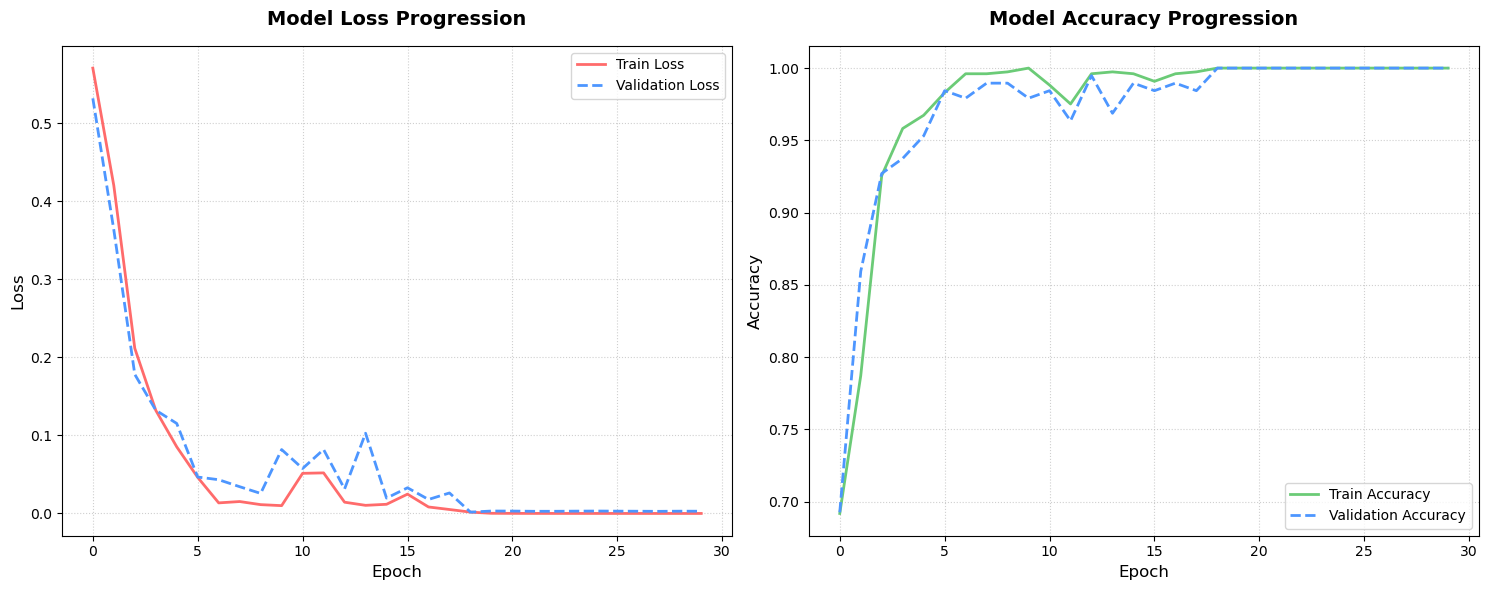

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Convert the best history to a DataFrame
history_df = pd.DataFrame(best_history.history)

# 2. Set up the plotting canvas with side-by-side charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left Subplot: Model Loss
ax1.plot(history_df['loss'], label='Train Loss', color='#FF6B6B', linewidth=2)
ax1.plot(history_df['val_loss'], label='Validation Loss', color='#4D96FF', linewidth=2, linestyle='--')
ax1.set_title('Model Loss Progression', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)

# Right Subplot: Model Accuracy
ax2.plot(history_df['accuracy'], label='Train Accuracy', color='#6BCB77', linewidth=2)
ax2.plot(history_df['val_accuracy'], label='Validation Accuracy', color='#4D96FF', linewidth=2, linestyle='--')
ax2.set_title('Model Accuracy Progression', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)

# Display the polished figure
plt.tight_layout()
plt.show()


**Which approach(es) did you find helpful to improve your model performance?**

In [ ]:
#The most significant factors in improving model performance were adjusting the learning rate to 0.01 and increasing the number of epochs to 30. 
#Compiling with metrics =['accuracy'] allows the model to be tracked
#Since if you use a smaller archetecture [16, 8] the model is forced to compress the features.  By moving to [64, 23, 16] the number of trainable weights increased. 
#This gave the model capacity to explore the 8 winning directions without overlapping or interference. 
#The following layers acted as decision-making layers.  In a more noisy data set these techniques may have resulted in overfitting, however in this case 
# the tic-tac-toe data set is clean and has no noise. 
